## Read Me

This is a flexible notebook for stepping through an annotation step by step given a specific scenario input. The notebook must be modified in order to select the directory and input file. This is not ideal, so we will have to come up with a better system!

## Set up

In [7]:
import json # !pip
import os
import textwrap
import pandas as pd
import importlib
import numpy as np
from pathlib import Path
import sys

In [8]:
ROOT_DIR = os.getcwd() + '/../'
sys.path.append(ROOT_DIR)

sys.path.append(ROOT_DIR+'src/')
print(ROOT_DIR)

/Users/emstrictly/Library/CloudStorage/Dropbox/2025_moral_scenario_annotation/code/em/graph_extract/run_annotation/../


In [9]:
import src.annotate_scenario as annotate_scenario
import src.prompts as prompts
import src.translate_to_vis as translate_to_vis
import src.node as node
import src.get_emb_distances as get_emb_distances
import src.utils as utils
import src.moral_projection as moral_projection
import src.generic_analysis_utils as generic_analysis_utils

import src.core_process as core_process
importlib.reload(annotate_scenario)
importlib.reload(translate_to_vis)
importlib.reload(prompts)
importlib.reload(node)
importlib.reload(utils)
importlib.reload(core_process)

/Users/emstrictly/Library/CloudStorage/Dropbox/2025_moral_scenario_annotation/code/em/graph_extract/graph_extract_venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


<module 'src.core_process' from '/Users/emstrictly/Library/CloudStorage/Dropbox/2025_moral_scenario_annotation/code/em/graph_extract/run_annotation/../src/core_process.py'>

In [10]:
# Automatically reload modules when they change
%load_ext autoreload
%autoreload 2

## Selet Scenario Input File

In [63]:
# set main paths
#SCENARIO_DIR = ROOT_DIR + "scenarios_inputs/" + "cheung_variants/"
SCENARIO_DIR = ROOT_DIR + "scenarios_inputs/" + "experimental/"
# DATA_DIR_HUMAN = ROOT_DIR + "human_data/" 
#OUTPUT_DIR = ROOT_DIR + "annotated_outputs/" + "cheung_variants/"
OUTPUT_DIR = ROOT_DIR + "annotated_outputs/" + "experimental/"

In [257]:
#set scenario file filename
FILENAME = 'garden.json'

#select scenario and action choice
SCENARIO_ID = 6
ACT_ID = '1'

#read in the scenario
scenario_json = utils.open_scenario(SCENARIO_DIR, FILENAME, SCENARIO_ID, ACT_ID)


I volunteer at a community garden in a neighborhood with strict drought rules. Each plot gets a
small weekly water allotment, and most of us have gotten used to timing our watering sessions,
swapping tips on mulch, and trying to keep our plants alive through the heat. One morning, while
grabbing a wheelbarrow from the shed, I noticed a narrow length of tubing running from the main
spigot to the back of one gardener's plot, clearly siphoning extra water in secret. It was tucked
behind a row of tall tomato cages, easy to miss unless you were standing right there. Her plants
looked great, and seeing the setup suddenly made all of that make sense. It was allowing her to use
way more water than what was allotted to her by bypassing the water meter. If the gardener continues
using all of this water, 10 of the other 20 gardeners' plants would suffer. 




In [ ]:
# print scenario json
# print(json.dumps(scenario_json, indent=4))

### Pretest deontology 

In [ ]:
core_process.process_values_minimal("get an abortion")

In [95]:
core_process.process_values_minimal("punch the bully in the head")

np.float64(-19.0)

In [21]:
core_process.process_values_minimal("get a vasectomy")

np.float64(-33.0)

In [22]:
core_process.process_values_minimal("use contraception")

np.float64(11.0)

#### There are 4 major stages of processing.

0. Entities
Label the entities (no human data)

1. Value Scores / "Deontology"
Score the action in moral value

2. Outcomes
Map action to probable outcomes 

3. Outcome Utilities
Consequentialist analysis of harms/benefits of each outcome to each entity

4. Outcome Links
Connection between each entity and each outcome, in terms of Cause, Intend, and Desire



## Go through annotation process step by step (replicates main function in annotate_scenario) 

In [258]:

# get the action choice and convert to two pronoun options (I and Ziv)
this_act = scenario_json['options'][ACT_ID]
this_act
# this_act_I = this_act
# this_act_Ziv = annotate_scenario.prompts.convert_I_Ziv(this_act_I)

# print(this_act_Ziv)
# print(this_act_I)

#get the scenario and convert to two pronoun options
this_scenario = scenario_json['text']
print(scenario_json['text'])
this_scenario_Ziv = annotate_scenario.prompts.convert_I_Ziv(this_scenario)
print("\n\nScenario:")
print(this_scenario_Ziv)
# print(this_scenario)


# create a dictionary to write out to csv later
scenario_dict = {'scenario': this_scenario, 'scenario_idx': scenario_json['id'],
                    'choice': this_act}


print('\n\nAction choice:') 
print(this_act)


I volunteer at a community garden in a neighborhood with strict drought rules. Each plot gets a small weekly water allotment, and most of us have gotten used to timing our watering sessions, swapping tips on mulch, and trying to keep our plants alive through the heat. One morning, while grabbing a wheelbarrow from the shed, I noticed a narrow length of tubing running from the main spigot to the back of one gardener's plot, clearly siphoning extra water in secret. It was tucked behind a row of tall tomato cages, easy to miss unless you were standing right there. Her plants looked great, and seeing the setup suddenly made all of that make sense. It was allowing her to use way more water than what was allotted to her by bypassing the water meter. If the gardener continues using all of this water, 10 of the other 20 gardeners' plants would suffer.


Scenario:
Ziv volunteers at a community garden in a neighborhood with strict drought rules. Each plot gets a small weekly water allotment, and

In [259]:

#initialize Graph object    
g = annotate_scenario.node.Graph()
g.reset()   
print('Graph g initialized and reset.')
g.set_version('f423a62e5bc14af918101b6d071460049c19d25a') #this should be the latest commit hash



Graph g initialized and reset.


#### Step 0. Get entities

In [260]:
#Step 0. Get entities

# identify all sentient beings, returning both pronoun forms and a string list
returned_beings = core_process.process_beings(this_scenario,this_act,g)
beings_I = returned_beings[0]
beings_Ziv = returned_beings[1]
beings_str_list = returned_beings[2]
g = returned_beings[3]
    
#update the scenario dict with the beings
scenario_dict["entities"] = beings_str_list



Identified these entities: 

1 narrator volunteer/gardener
1 gardener secretly siphoning extra water
10 other gardeners whose plants would suffer if the siphoning continues
10 other gardeners whose plants would not suffer if the siphoning continues
I


#### Step 1. Deontology / Action Value Scores

In [261]:
#Step 1.  #ACTION VALUE SCORES

#call the process_values function to rate the moral goodness or wrongness of the action with no context
deontic_value,g  =  core_process.process_values_simple(this_act,g) 
print(deontic_value)

    

-12.0


#### Step 2. Anticipated Outcomes

In [262]:
#Step 2. Outcomes
processed_events = core_process.process_outcomes(this_scenario, this_act)
events_I = processed_events[1]
events_Ziv = processed_events[0]
print("\n".join(events_Ziv))         
scenario_dict["outcomes"]= events_I

The gardener feels publicly embarrassed
The gardener feels accused and defensive
Ziv feels stress from the confrontation
Other gardeners learn about the unauthorized water siphoning
Other gardeners feel angry about the unfair water use
The community meeting becomes tense
Garden organizers scrutinize the gardener's plot and water use
The unauthorized extra water use is stopped
The other gardeners keep more of their allotted water


#### Step 3. Outcome Utilities

In [263]:
events_Ziv

['The gardener feels publicly embarrassed',
 'The gardener feels accused and defensive',
 'Ziv feels stress from the confrontation',
 'Other gardeners learn about the unauthorized water siphoning',
 'Other gardeners feel angry about the unfair water use',
 'The community meeting becomes tense',
 "Garden organizers scrutinize the gardener's plot and water use",
 'The unauthorized extra water use is stopped',
 'The other gardeners keep more of their allotted water']

In [11]:
## process utility via projection onto "abstract" morality vector - Hitler/rape to love/freedom
import src.embedding_utils as embedding_utils

def utility_proj_abstract_defs(item):

   attributes_morality_high = ['love','freedom', 'hope', 'wonder',  'connection',  'bliss'] 
   attributes_morality_low = ['murdering','raping', 'Hitler',  'nazis', 'ransomware', 'massacres'] 
   
   this_projector = embedding_utils.EmbeddingProjector('openai')
   
   morality_vector = this_projector.return_embedding_diff(attributes_morality_high, attributes_morality_low)
   item_projection = this_projector.get_projections([item], morality_vector)
   
   this_score = round(item_projection['projection'].iloc[0]*1000, 0)
 
   return this_score


In [12]:
## process utility via projection onto utility vector - low (poverty/harm/disadvantage) to high (welfare/benefit/utility)

def utility_proj_utility_defs(item):

   attributes_utility_low = ['harm', 'disadvantage', 'poverty', 'unhappiness'] 
   attributes_utility_high = ['welfare', 'benefit', 'prosperity', 'well-being']
   
   this_projector = embedding_utils.EmbeddingProjector('openai')
   
   utility_vector = this_projector.return_embedding_diff(attributes_utility_high, attributes_utility_low)
   item_projection = this_projector.get_projections([item], utility_vector)
   
   this_score = round(item_projection['projection'].iloc[0]*1000, 0)
 
   return this_score

In [264]:
events_Ziv
for event in events_Ziv:
    utility_utility = utility_proj_utility_defs(event)
    abstract_utility = utility_proj_abstract_defs(event)
    print(event)
    print("Abstract utility projection score is %s and welfare utility projection score is %s" % (utility_utility, abstract_utility))

The gardener feels publicly embarrassed
Abstract utility projection score is -51.0 and welfare utility projection score is 12.0
The gardener feels accused and defensive
Abstract utility projection score is -43.0 and welfare utility projection score is -20.0
Ziv feels stress from the confrontation
Abstract utility projection score is -41.0 and welfare utility projection score is 27.0
Other gardeners learn about the unauthorized water siphoning
Abstract utility projection score is -46.0 and welfare utility projection score is -37.0
Other gardeners feel angry about the unfair water use
Abstract utility projection score is -88.0 and welfare utility projection score is -36.0
The community meeting becomes tense
Abstract utility projection score is -69.0 and welfare utility projection score is -49.0
Garden organizers scrutinize the gardener's plot and water use
Abstract utility projection score is 7.0 and welfare utility projection score is -18.0
The unauthorized extra water use is stopped
Ab

In [265]:
impacts_list_2 = core_process.process_impacts(this_scenario_Ziv, this_act, events_Ziv, events_I,beings_Ziv,g) 


Processing impacts of event: The gardener feels publicly embarrassed
Consider the event that the gardener feels publicly embarrassed. How does this event impact the character(s) 1 narrator volunteer/gardener?
Consider the event that the gardener feels publicly embarrassed. How does this event impact the character(s) Ziv, a gardener, secretly siphoning extra water?
Consider the event that the gardener feels publicly embarrassed. How does this event impact the character(s) 10 other gardeners whose plants would suffer if the siphoning continues?
Consider the event that the gardener feels publicly embarrassed. How does this event impact the character(s) 10 other gardeners whose plants would not suffer if the siphoning continues?
Consider the event that the gardener feels publicly embarrassed. How does this event impact the character(s) Ziv?
{'1 narrator volunteer/gardener': -30, 'Ziv, a gardener, secretly siphoning extra water': -30, '10 other gardeners whose plants would suffer if the si

In [231]:
utility_proj_utility_defs("The secret tubing stops delivering extra water to the gardener's plot")

np.float64(-44.0)

In [154]:
core_process.process_util_minimal("The gardener is tortured")

np.float64(-23.0)

In [108]:
core_process.process_util_minimal(events_I[2])

np.float64(-3.0)

In [109]:
core_process.process_util_minimal(events_I[3])

np.float64(7.0)

In [274]:
core_process.process_util_minimal(events_I[4])

np.float64(-36.0)

In [275]:
events_I[4]

'Other gardeners feel angry about the unfair water use'

In [ ]:
## trying alternate prompt
def convert_lower(sentence):
    # convert to lower case except instances of Ziv
    new_s = sentence.lower()
    new_s = new_s.replace("ziv","Ziv")
    new_s = new_s.replace("ziv's","Ziv's")

    return new_s

c
    

def process_utilities(this_scenario_Ziv, this_act, events_Ziv, events_I, beings_fixed_Ziv, g):


  act_node = g.return_node(this_act)[0]   

  #create list of impacts on each being
  impacts_list = []
  impacts_df = []

  for this_evt_Ziv, this_evt_I in zip(events_Ziv,events_I):

    print('\nProcessing impacts of event: '+this_evt_Ziv)

    #create a node for this "event"
    this_out_node = g.add_node(node.Node(this_evt_I,'event'))

    #create a link between act and event
    this_link = g.add_link(node.Link('e_link',''))
    act_node.link_link(this_link,this_out_node)

    impacts_Ziv = {}
    for being in beings_fixed_Ziv:      

      #  this_score = prompts.get_impacts_Ziv_single(this_scenario_Ziv, this_act this_evt_Ziv, being)   

       this_score = get_utilities_Ziv_single_noscene( this_evt_Ziv, being)   
       impacts_Ziv[being] = this_score['score']
    
    
    # beings_string = ', '.join(beings_fixed_Ziv)
    # impacts_Ziv = prompts.get_impacts_Ziv_multi(this_scenario_Ziv, this_act, this_evt_Ziv, beings_string) 

    print(impacts_Ziv)


    try:
       scored_values = list(impacts_Ziv.values())
    except:
       #list of NAs equal to length of beings
       scored_values = [None] * len(beings_fixed_Ziv)

    # # # try to align the returned beings list with the known beings list
    # # # create Ziv version of beings
    # # # convert both into sets
    # beings_known_set = set(beings_fixed_Ziv)
    # beings_found_list = list(impacts_Ziv.keys())


    # beings_not_found = []
    # for this_b in beings_found_list:
    #   if(this_b in beings_known_set):
    #     beings_known_set.discard(this_b)
    #   else:
    #     beings_not_found.append(this_b)
     

    # #handle any remaining beings in being_set were not identified
    # #some known beings were not found
    # # beings_known are any known beings not found in returned list
    # # beings_not_found are any in the returned list not found in known set
    # if(beings_known_set and beings_not_found):                        
    #       #if there is one known unfound and one returned unfound, assume they match and replace with each other

    #       if(len(beings_known_set)==len(beings_not_found)==1):
    #           print('\nReplacing '+beings_not_found[0]+' with: ')
    #           print(beings_known_set)
    #           beings_found_list.remove(beings_not_found[0]) 
    #           beings_found_list.append(beings_known_set.pop())
              
    #       else:
    #       #the main errors arise if there is a returned being not in the known_beings list
    #       #for each one of those, see if you can find its corresponding item by semantic sim. 
    #         for item in beings_not_found:

    #           matches = prompts.find_semantic_match(item,beings_fixed_Ziv)
    #           # print(scored_values)
    #           # print(beings_found_list)
    #           #find the index of this item in the beings_found_list
    #           index = beings_found_list.index(item)


    #           try:
    #             rep_item = matches[item]
    #             beings_found_list[index] = rep_item
    #           except:
    #             scored_values.pop(index)
    #             beings_found_list.pop(index)

             


    # print("Scored impacts for these beings:")
    # print(beings_found_list)
    # print("Scored values:")
    # print(scored_values)

    #add node links, converting Ziv to I again

    beings_found_list = beings_fixed_Ziv

   
    #convert item "Ziv" to "I" in beings_found_list
    try:
        beings_found_list_I = []
        for x in beings_found_list:
          if(x!='I'):
                x=x.lower()                
          beings_found_list_I.append(prompts.convert_Ziv_I(x))
    except:
       print('error with beings found list!')
       print(beings_found_list)
       beings_found_list_I=beings_found_list
    
    # print(beings_found_list_I)
    # g.print_graph()
    

    for being,score in zip(beings_found_list_I,scored_values):
        this_link = g.add_link(node.Link('utility',str(score)))
        # this_b_node = g.return_node(being.lstrip())[0]
        # this_b_node = find_node_case_insensitive(g, being)
        if g.return_node(being.lower()):
            this_b_node = g.return_node(being.lower())[0]
        else:
           print('not working')
            # this_b_node = g.return_node(being.lstrip()[0].upper() + being.lstrip()[1:])[0]
        this_event_node = g.return_node(this_evt_I)[0]
        this_event_node.link_link(this_link,this_b_node)
        items_to_write = ",".join([this_evt_I,being,str(score)])
        impacts_list.append(items_to_write)

    impacts_df.append([this_evt_I,beings_found_list_I, scored_values])
    # print(impacts_df)


  return(impacts_list,impacts_df, g)

In [240]:
#Step 3. Outcome utilities

impacts_list_2 = core_process.process_impacts(this_scenario_Ziv, this_act, events_Ziv, events_I,beings_Ziv,g) 



Processing impacts of event: The secret tubing stops delivering extra water to the gardener's plot
Consider the event that the secret tubing stops delivering extra water to the gardener's plot. How does this event impact the character(s) Ziv?
Consider the event that the secret tubing stops delivering extra water to the gardener's plot. How does this event impact the character(s) the gardener secretly siphoning extra water?
Consider the event that the secret tubing stops delivering extra water to the gardener's plot. How does this event impact the character(s) 5 other gardeners whose plants would suffer if the siphoning continues?
Consider the event that the secret tubing stops delivering extra water to the gardener's plot. How does this event impact the character(s) 15 other gardeners whose plants would not suffer from the siphoning continuing?
{'Ziv': -40, 'the gardener secretly siphoning extra water': -40, '5 other gardeners whose plants would suffer if the siphoning continues': 65,

In [278]:
utilities_list_2 = process_utilities(this_scenario_Ziv, this_act, events_Ziv, events_I,beings_Ziv,g) 


Processing impacts of event: The gardener feels publicly embarrassed
Consider the event that the gardener feels publicly embarrassed. What utility does this event confer to the character(s) 1 narrator volunteer/gardener?
Consider the event that the gardener feels publicly embarrassed. What utility does this event confer to the character(s) Ziv, a gardener, secretly siphoning extra water?
Consider the event that the gardener feels publicly embarrassed. What utility does this event confer to the character(s) 10 other gardeners whose plants would suffer if the siphoning continues?
Consider the event that the gardener feels publicly embarrassed. What utility does this event confer to the character(s) 10 other gardeners whose plants would not suffer if the siphoning continues?
Consider the event that the gardener feels publicly embarrassed. What utility does this event confer to the character(s) Ziv?
{'1 narrator volunteer/gardener': -35, 'Ziv, a gardener, secretly siphoning extra water': 

In [303]:
impacts_list_2[1][1]

['The gardener feels accused and defensive',
 ['1 narrator volunteer/gardener',
  'I, a gardener, secretly siphoning extra water',
  '10 other gardeners whose plants would suffer if the siphoning continues',
  '10 other gardeners whose plants would not suffer if the siphoning continues',
  'I'],
 [-35, -35, -35, -2, 0]]

In [304]:
utilities_list_2[1][1]

['The gardener feels accused and defensive',
 ['1 narrator volunteer/gardener',
  'I, a gardener, secretly siphoning extra water',
  '10 other gardeners whose plants would suffer if the siphoning continues',
  '10 other gardeners whose plants would not suffer if the siphoning continues',
  'I'],
 [-25, -35, -25, 8, 0]]

#### Step 4. Cause / Intend / Know Links

In [283]:
#Step 4. causal / intentional / knowledge links -- run on currently generated event/outcome list
output_links = core_process.process_causal_links(this_scenario_Ziv, events_Ziv, events_I, this_act,g)    


Processing event: The gardener feels publicly embarrassed
{'cause': 'yes', 'intend': 'yes', 'know': 'yes'}
CKI links for I
C+I+K+

Processing event: The gardener feels accused and defensive
{'cause': 'yes', 'intend': 'no', 'know': 'no'}
CKI links for I
C+I-K-

Processing event: I feel stress from the confrontation
{'cause': 'yes', 'intend': 'no', 'know': 'no'}
CKI links for I
C+I-K-

Processing event: Other gardeners learn about the unauthorized water siphoning
{'cause': 'yes', 'intend': 'yes', 'know': 'yes'}
CKI links for I
C+I+K+

Processing event: Other gardeners feel angry about the unfair water use
{'cause': 'yes', 'intend': 'no', 'know': 'yes'}
CKI links for I
C+I-K+

Processing event: The community meeting becomes tense
{'cause': 'yes', 'intend': 'no', 'know': 'no'}
CKI links for I
C+I-K-

Processing event: Garden organizers scrutinize the gardener's plot and water use
{'cause': 'yes', 'intend': 'yes', 'know': 'no'}
CKI links for I
C+I+K-

Processing event: The unauthorized ext

#### Step 5. Write out the results

In [ ]:
narrative = FILENAME.split('.')[0]
this_output_filename = f"{OUTPUT_DIR}/{narrative}_{SCENARIO_ID}_choice_{ACT_ID}.json"

In [ ]:
#optional -- write out the results 
print('\n\nWriting to file: '+this_output_filename)
g_print = g.print_graph()
utils.write_jsonlines(this_output_filename, g_print)
print('\n\n')


translate_to_vis.main(this_output_filename)


## Playing with utility
1. Projections
    a. Onto utility definition vector (harm/low-well-being to benefit/happiness)
    b. Onto abstract morality vector (ransomware/Nazis to love/dreams)
2. Prompting
    

In [ ]:
high_utility_actions = ['having satisfying, consensual sex with the love of your life', 'earning many millions of dollars', 'getting married to your soulmate', 'winning the lottery', 'finding true love', 'achieving your lifelong dream', 'being reunited with a loved one after a long separation', 'receiving a prestigious award']
low_utility_actions = ['being tortured', 'the death of all your friends and family', 'being imprisoned for life', 'being betrayed by a loved one', 'losing all your possessions and wealth', 'suffering from a terminal illness', 'experiencing a natural disaster that destroys your home and community', 'being falsely accused and convicted of a crime you did not commit', 'losing the ability to communicate or interact with others', 'being subjected to prolonged isolation or confinement']
neutral_utility_actions = ['blinking', 'pupils constricting', 'smooth muscles contracting', 'fingernails growing', 'yawning', 'staring into space','sitting in a chair']

In [309]:
for action in high_utility_actions:
    print(f"Action: {action}")
    utility = utility_proj_utility_defs(action)
    print(f"Utility score: {utility}")

Action: having satisfying, consensual sex with the love of your life
Utility score: 45.0
Action: being given 10 million dollars
Utility score: 59.0
Action: getting married to your soulmate
Utility score: 25.0
Action: winning the lottery
Utility score: 59.0
Action: finding true love
Utility score: 5.0
Action: achieving your lifelong dream
Utility score: 52.0
Action: being reunited with a loved one after a long separation
Utility score: 47.0
Action: receiving a prestigious award or recognition
Utility score: 75.0
Action: making a significant positive impact on the world
Utility score: 91.0
Action: overcoming a major personal challenge or obstacle
Utility score: 0.0


In [310]:
for action in high_utility_actions:
    print(f"Action: {action}")
    utility = utility_proj_abstract_defs(action)
    print(f"Utility score: {utility}")

Action: having satisfying, consensual sex with the love of your life
Utility score: 113.0
Action: being given 10 million dollars
Utility score: 30.0
Action: getting married to your soulmate
Utility score: 88.0
Action: winning the lottery
Utility score: 33.0
Action: finding true love
Utility score: 157.0
Action: achieving your lifelong dream
Utility score: 122.0
Action: being reunited with a loved one after a long separation
Utility score: 137.0
Action: receiving a prestigious award or recognition
Utility score: 55.0
Action: making a significant positive impact on the world
Utility score: 64.0
Action: overcoming a major personal challenge or obstacle
Utility score: 91.0


In [311]:
for action in low_utility_actions:
    print(f"Action: {action}")
    utility = utility_proj_utility_defs(action)
    print(f"Utility score: {utility}")

Action: being tortured
Utility score: -75.0
Action: the death of all your friends and family
Utility score: -73.0
Action: being imprisoned for life
Utility score: -43.0
Action: being betrayed by a loved one
Utility score: -90.0
Action: losing all your possessions and wealth
Utility score: -49.0
Action: suffering from a terminal illness
Utility score: -37.0
Action: experiencing a natural disaster that destroys your home and community
Utility score: -78.0
Action: being falsely accused and convicted of a crime you did not commit
Utility score: -51.0
Action: losing the ability to communicate or interact with others
Utility score: -91.0
Action: being subjected to prolonged isolation or confinement
Utility score: -50.0


In [312]:
for action in low_utility_actions:
    print(f"Action: {action}")
    utility = utility_proj_abstract_defs(action)
    print(f"Utility score: {utility}")

Action: being tortured
Utility score: -74.0
Action: the death of all your friends and family
Utility score: -36.0
Action: being imprisoned for life
Utility score: -57.0
Action: being betrayed by a loved one
Utility score: 1.0
Action: losing all your possessions and wealth
Utility score: -20.0
Action: suffering from a terminal illness
Utility score: -8.0
Action: experiencing a natural disaster that destroys your home and community
Utility score: -39.0
Action: being falsely accused and convicted of a crime you did not commit
Utility score: -28.0
Action: losing the ability to communicate or interact with others
Utility score: 10.0
Action: being subjected to prolonged isolation or confinement
Utility score: -25.0


In [4]:
def prompt_utility_via_utilitarian_def(outcome):
    system_prompt_content = f"""
    You are an expert in utilitarian ethics. Utilitarian ethics is a moral philosophy that evaluates the rightness or wrongness of actions based on their consequences, specifically in terms of maximizing overall happiness or well-being. Utility is defined as the satisfaction, well-being, or benefit a person receives as the result of an event.
    
    You will be given an outcome and asked to evaluate the utility that that event would confer to a person who experiences it. Rate its utility using a scale from -100 to +100, where a rating of -100 indicates that the outcome will cause the character maximal harm (the worst thing that could happen to them), while a rating of +100 indicates that it will cause the character maximal benefit (the best thing that could happen to them). If the outcome does not confer any benefits or harm, or if the harm and benefits overall are equal, return a rating of 0.
    
    Respond ONLY with a JSON object in the form {{"utility": <integer>}}, where the integer is your rating from -100 to +100.
    """
    
    user_prompt_content = f'Here is the outcome: {outcome}. How much utility is generated by this outcome?'
    
    return utils.get_response_dict(system_prompt_content, user_prompt_content)

In [5]:
def prompt_utility_via_abstract_def(outcome):
    system_prompt_content = f"""
    You are a helpful assistant who is an expert at understanding human situations. You will be given an action and asked to evaluate the impact an event will have. Rate the impact using a scale from -100 to +100, where a rating of -100 indicates that the outcome will cause substantial harm (e.g., the worst possible thing that could happen to someone, such as a very painful death), while a rating of +100 indicates that it will substantial benefit (the best possible thing that could happen to someone, such as having all of their dreams come true). If the outcome is not likely to have much impact, or the harm and benefit are equal, return a rating closer to 0. Return a json object called "score" with your rating.
    
    Respond ONLY with a JSON object in the form {{"utility": <integer>}}, where the integer is your rating from -100 to +100.
    """
    
    user_prompt_content = f'Here is the outcome: {outcome}. How much utility is generated by this outcome?'
    
    return utils.get_response_dict(system_prompt_content, user_prompt_content)

In [346]:
for action in low_utility_actions:
    utility = prompt_utility_via_utilitarian_def(action)
    print(f"Action: {action}. The utility score is {utility}")
    

Action: being tortured. The utility score is {'utility': -95}
Action: the death of all your friends and family. The utility score is {'utility': -95}
Action: being imprisoned for life. The utility score is {'utility': -95}
Action: being betrayed by a loved one. The utility score is {'utility': -78}
Action: losing all your possessions and wealth. The utility score is {'utility': -85}
Action: suffering from a terminal illness. The utility score is {'utility': -95}
Action: experiencing a natural disaster that destroys your home and community. The utility score is {'utility': -90}
Action: being falsely accused and convicted of a crime you did not commit. The utility score is {'utility': -92}
Action: losing the ability to communicate or interact with others. The utility score is {'utility': -95}
Action: being subjected to prolonged isolation or confinement. The utility score is {'utility': -85}


In [347]:
for action in low_utility_actions:
    utility = prompt_utility_via_abstract_def(action)
    print(f"Action: {action}. The utility score is {utility}")
    

Action: being tortured. The utility score is {'utility': -98}
Action: the death of all your friends and family. The utility score is {'utility': -98}
Action: being imprisoned for life. The utility score is {'utility': -85}
Action: being betrayed by a loved one. The utility score is {'utility': -72}
Action: losing all your possessions and wealth. The utility score is {'utility': -75}
Action: suffering from a terminal illness. The utility score is {'utility': -90}
Action: experiencing a natural disaster that destroys your home and community. The utility score is {'utility': -85}
Action: being falsely accused and convicted of a crime you did not commit. The utility score is {'utility': -85}
Action: losing the ability to communicate or interact with others. The utility score is {'utility': -92}
Action: being subjected to prolonged isolation or confinement. The utility score is {'utility': -83}


In [16]:
for action in high_utility_actions:
    utility = prompt_utility_via_utilitarian_def(action)
    print(f"Action: {action}. The utility score is {utility}")
    

Action: having satisfying, consensual sex with the love of your life. The utility score is {'utility': 82}
Action: being given 10 million dollars. The utility score is {'utility': 90}
Action: getting married to your soulmate. The utility score is {'utility': 90}
Action: winning the lottery. The utility score is {'utility': 80}
Action: finding true love. The utility score is {'utility': 85}
Action: achieving your lifelong dream. The utility score is {'utility': 90}
Action: being reunited with a loved one after a long separation. The utility score is {'utility': 80}
Action: receiving a prestigious award or recognition. The utility score is {'utility': 55}


In [349]:
for action in high_utility_actions:
    utility = prompt_utility_via_abstract_def(action)
    print(f"Action: {action}. The utility score is {utility}")
    

Action: having satisfying, consensual sex with the love of your life. The utility score is {'utility': 78}
Action: being given 10 million dollars. The utility score is {'utility': 85}
Action: getting married to your soulmate. The utility score is {'utility': 85}
Action: winning the lottery. The utility score is {'utility': 78}
Action: finding true love. The utility score is {'utility': 85}
Action: achieving your lifelong dream. The utility score is {'utility': 90}
Action: being reunited with a loved one after a long separation. The utility score is {'utility': 75}
Action: receiving a prestigious award or recognition. The utility score is {'utility': 55}
Action: making a significant positive impact on the world. The utility score is {'utility': 95}
Action: overcoming a major personal challenge or obstacle. The utility score is {'utility': 72}


In [45]:
neutral_utility_actions = ['blinking', 'pupils constricting', 'smooth muscles contracting', 'fingernails growing', 'yawning', 'staring into space','sitting in a chair']

In [46]:
for action in neutral_utility_actions:
    utility = utility_proj_utility_defs(action)
    print(f"Action: {action}. The utility score is {utility}")

Action: blinking. The utility score is -3.0
Action: pupils constricting. The utility score is -33.0
Action: smooth muscles contracting. The utility score is -53.0
Action: fingernails growing. The utility score is 14.0
Action: yawning. The utility score is -23.0
Action: staring into space. The utility score is -28.0
Action: sitting in a chair. The utility score is -35.0


In [337]:
for action in neutral_utility_actions:
    utility = utility_proj_abstract_defs(action)
    print(f"Action: {action}. The utility score is {utility}")

Action: blinking. The utility score is 59.0
Action: pupils constricting. The utility score is -3.0
Action: smooth muscles contracting. The utility score is -39.0


In [342]:
for action in neutral_utility_actions:
    utility = get_utility_prompt(action)
    utility_score = utility['utility']
    print(f"Action: {action}. The utility score is {utility_score}")  

Action: blinking. The utility score is 1
Action: pupils constricting. The utility score is 3
Action: smooth muscles contracting. The utility score is 2


In [29]:
def get_utility_projection_df(actions):
    utility_scores = []
    for action in actions:
        utility_utility = utility_proj_utility_defs(action)
        abstract_utility = utility_proj_abstract_defs(action)
        prompt_utility = prompt_utility_via_utilitarian_def(action)['utility']
        prompt_impact = prompt_utility_via_abstract_def(action)['utility']
        utility_scores.append({
            'action': action,
            'utility_projection': utility_utility,
            'abstract_projection': abstract_utility,
            'prompt_utility_based': prompt_utility,
            'prompt_impact_based': prompt_impact
        })
    return pd.DataFrame(utility_scores)

In [30]:
high_util_df = get_utility_projection_df(high_utility_actions)

In [ ]:
low_util_df = get_utility_projection_df(low_utility_actions)

In [33]:
neutral_utility_df = get_utility_projection_df(neutral_utility_actions)

In [43]:
def plot_utility_comparison(df, title):
    import matplotlib.pyplot as plt
    import numpy as np

    x = np.arange(len(df['action']))  # the label locations
    width = 0.2  # the width of the bars

    fig, ax = plt.subplots(figsize=(12, 6))
    rects1 = ax.bar(x - width, df['utility_projection'], width, label='Projection Based: Utility-Definition')
    rects2 = ax.bar(x, df['abstract_projection'], width, label='Projection Based: Abstract-Definition')
    rects3 = ax.bar(x + width, df['prompt_utility_based'], width, label='Prompt Based: Get Utility')
    rects4 = ax.bar(x + 2*width, df['prompt_impact_based'], width, label='Prompt Based: Get Impacts')

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Utility Scores')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(df['action'], rotation=45, ha='right')
    ax.legend()

    fig.tight_layout()
    plt.show()

In [34]:
total_util_df = pd.concat([high_util_df, neutral_utility_df, low_util_df], ignore_index=True)

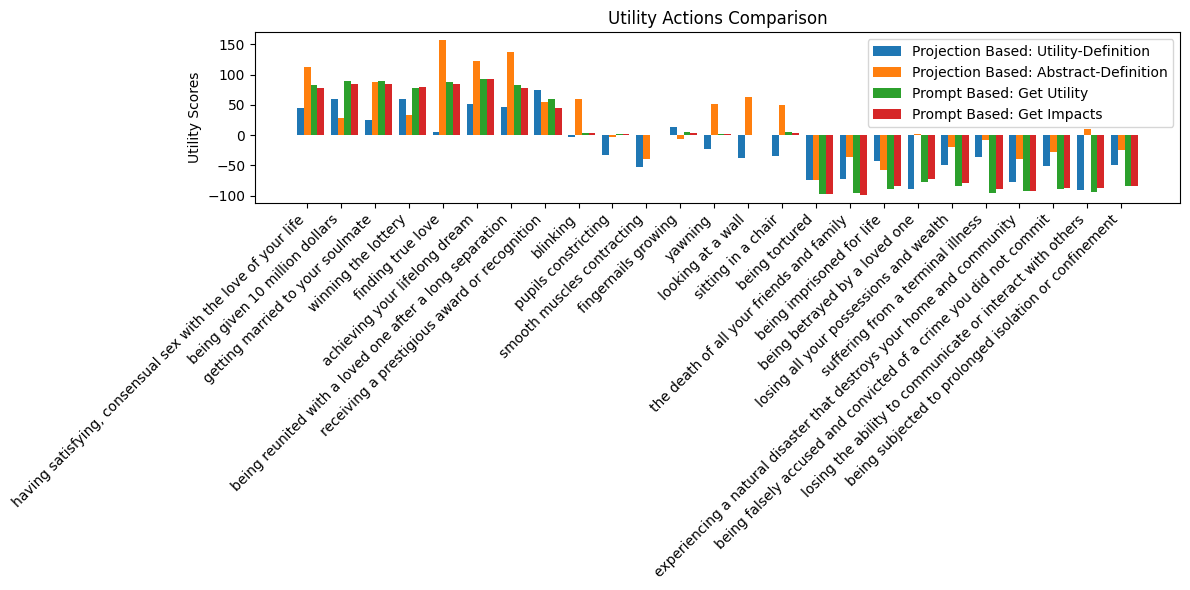

In [44]:
plot_utility_comparison(total_util_df, 'Utility Actions Comparison')

In [52]:
# explore franken stimuli
HUMAN_DATA_DIR = ROOT_DIR + "human_data/"
FRANKEN_STIMULI_DIR = HUMAN_DATA_DIR + "franken/"
harm_good_ratings = json.loads(open(FRANKEN_STIMULI_DIR + "exp1_harm-vs-good-rating/exp1_unique_stimuli.json", 'r').read())

In [61]:
franken_good_actions = []
franken_harm_actions = []
for item in harm_good_ratings:
    if item['type']=='good':
        franken_good_actions.append(item['target'])
    elif item['type']=='harm':
        franken_harm_actions.append(item['target'])

In [66]:
## process utility via projection onto "franken_harm_good" morality vector - harm to good
import src.embedding_utils as embedding_utils
import random

def utility_proj_franken_harm_good(item):

   attributes_morality_high = random.sample(franken_good_actions, k=10)
   attributes_morality_low = random.sample(franken_harm_actions, k=10) 
   #start with random sample to avoid computational cost
   
   this_projector = embedding_utils.EmbeddingProjector('openai')
   
   morality_vector = this_projector.return_embedding_diff(attributes_morality_high, attributes_morality_low)
   item_projection = this_projector.get_projections([item], morality_vector)
   
   this_score = round(item_projection['projection'].iloc[0]*1000, 0)
 
   return this_score


In [67]:
for action in neutral_utility_actions:
    franken_utility = utility_proj_franken_harm_good(action)
    print(f"Action: {action}. The franken utility score is {franken_utility}")

Action: blinking. The franken utility score is -10.0
Action: pupils constricting. The franken utility score is -19.0
Action: smooth muscles contracting. The franken utility score is -23.0
Action: fingernails growing. The franken utility score is -0.0
Action: yawning. The franken utility score is -2.0
Action: staring into space. The franken utility score is -43.0
Action: sitting in a chair. The franken utility score is -12.0


In [68]:
for action in high_utility_actions:
    franken_utility = utility_proj_franken_harm_good(action)
    print(f"Action: {action}. The franken utility score is {franken_utility}")

Action: having satisfying, consensual sex with the love of your life. The franken utility score is 19.0
Action: being given 10 million dollars. The franken utility score is -9.0
Action: getting married to your soulmate. The franken utility score is 39.0
Action: winning the lottery. The franken utility score is 33.0
Action: finding true love. The franken utility score is 11.0
Action: achieving your lifelong dream. The franken utility score is 48.0
Action: being reunited with a loved one after a long separation. The franken utility score is 13.0
Action: receiving a prestigious award or recognition. The franken utility score is 64.0


In [69]:
for action in low_utility_actions:
    franken_utility = utility_proj_franken_harm_good(action)
    print(f"Action: {action}. The franken utility score is {franken_utility}")

Action: being tortured. The franken utility score is -113.0
Action: the death of all your friends and family. The franken utility score is -61.0
Action: being imprisoned for life. The franken utility score is 2.0
Action: being betrayed by a loved one. The franken utility score is -53.0
Action: losing all your possessions and wealth. The franken utility score is -77.0
Action: suffering from a terminal illness. The franken utility score is -66.0
Action: experiencing a natural disaster that destroys your home and community. The franken utility score is -24.0
Action: being falsely accused and convicted of a crime you did not commit. The franken utility score is -6.0
Action: losing the ability to communicate or interact with others. The franken utility score is -67.0
Action: being subjected to prolonged isolation or confinement. The franken utility score is -62.0
